In [50]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


In [51]:
df = pd.read_csv("artifacts/data/clean_data.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df=df.drop(columns=['day','month','day_of_week'])

# Features & target
features = df.drop(columns=["Date", "Average_Price"])
target = df["Average_Price"]





In [52]:
features.head()

,Supply_Volume,USD_TO_NPR,Diesel,is_festival,Season_Autumn,Season_Monsoon,Season_Spring,Season_Winter,Inflation,Dhading_Wind_Speed,...,Kavre_Rainfall_MM,Kavre_Air_Pressure,Sarlahi_Wind_Speed,Sarlahi_Temperature,Sarlahi_Precipitation,Sarlahi_Rainfall_MM,Sarlahi_Air_Pressure,is_weekend,month_sin,month_cos
0,8000.0,119.24,119.0,0,False,False,False,True,6.03,3.244772,...,0.0,1021.32495,5.326186,13.361168,0.0,0.0,1020.31244,1,0.5,0.866025
1,8000.0,119.24,119.0,0,False,False,False,True,6.03,3.520784,...,0.0,1020.13745,5.971028,12.967416,0.0,0.0,1018.67505,1,0.5,0.866025
2,22375.0,119.24,119.0,0,False,False,False,True,6.03,3.912350,...,0.0,1018.20844,6.731186,12.807000,0.0,0.0,1017.00410,0,0.5,0.866025
3,8000.0,119.12,119.0,0,False,False,False,True,6.03,3.496666,...,0.0,1018.35425,4.318778,12.761169,0.0,0.0,1017.64180,0,0.5,0.866025
4,32500.0,119.59,119.0,0,False,False,False,True,6.03,3.259311,...,0.0,1018.16656,4.947710,13.677834,0.0,0.0,1017.07930,0,0.5,0.866025


In [53]:
features['Supply_Volume'].tail()

1384    1830.0
1385    1220.0
1386     610.0
1387     610.0
1388     610.0
Name: Supply_Volume, dtype: float64

In [54]:
# Scale
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(features)
y_scaled = scaler_y.fit_transform(target.values.reshape(-1,1))

In [55]:
param_grid = {
    "hidden_size": [32, 64, 128],
    "num_layers": [1, 2,3],
    "lr": [0.001, 0.005],
    "batch_size": [16, 32,64]
}

import itertools
all_combinations = list(itertools.product(
    param_grid["hidden_size"],
    param_grid["num_layers"],
    param_grid["lr"],
    param_grid["batch_size"]
))


In [56]:
window = 7
X_seq, y_seq = [], []

for i in range(window, len(X_scaled)):
    X_seq.append(X_scaled[i-window:i])
    y_seq.append(y_scaled[i])

X_seq = torch.tensor(np.array(X_seq), dtype=torch.float32)
y_seq = torch.tensor(np.array(y_seq), dtype=torch.float32)

split = int(0.8*len(X_seq))
train_dataset = TensorDataset(X_seq[:split], y_seq[:split])
test_dataset  = TensorDataset(X_seq[split:], y_seq[split:])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16)


In [57]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # last timestep
        return self.fc(out)

input_size = X_seq.shape[2]
model = LSTMModel(input_size)


In [58]:
def train_evaluate_lstm(input_size, hidden_size, num_layers, lr, epochs=20, batch_size=16):
    model = LSTMModel(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size)
    
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        # Train
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()*xb.size(0)
        train_losses.append(epoch_loss/len(train_loader.dataset))
        
        # Validate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                out = model(xb)
                val_loss += criterion(out, yb).item()*xb.size(0)
        val_losses.append(val_loss/len(test_loader.dataset))
    
    return model, train_losses, val_losses


In [59]:
best_val = float("inf")
best_params = None
best_model = None

for hs, nl, lr, bs in all_combinations:
    print(f"Testing: hidden={hs}, layers={nl}, lr={lr}, batch={bs}")
    model, train_losses, val_losses = train_evaluate_lstm(input_size=X_seq.shape[2],
                                                         hidden_size=hs,
                                                         num_layers=nl,
                                                         lr=lr,
                                                         epochs=20,
                                                         batch_size=bs)
    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        best_params = {"hidden_size": hs, "num_layers": nl, "lr": lr, "batch_size": bs}
        best_model = model

print("Best Val Loss:", best_val)
print("Best Params:", best_params)


Testing: hidden=32, layers=1, lr=0.001, batch=16


Testing: hidden=32, layers=1, lr=0.001, batch=32
Testing: hidden=32, layers=1, lr=0.001, batch=64
Testing: hidden=32, layers=1, lr=0.005, batch=16
Testing: hidden=32, layers=1, lr=0.005, batch=32
Testing: hidden=32, layers=1, lr=0.005, batch=64
Testing: hidden=32, layers=2, lr=0.001, batch=16
Testing: hidden=32, layers=2, lr=0.001, batch=32
Testing: hidden=32, layers=2, lr=0.001, batch=64
Testing: hidden=32, layers=2, lr=0.005, batch=16
Testing: hidden=32, layers=2, lr=0.005, batch=32
Testing: hidden=32, layers=2, lr=0.005, batch=64
Testing: hidden=32, layers=3, lr=0.001, batch=16
Testing: hidden=32, layers=3, lr=0.001, batch=32
Testing: hidden=32, layers=3, lr=0.001, batch=64
Testing: hidden=32, layers=3, lr=0.005, batch=16
Testing: hidden=32, layers=3, lr=0.005, batch=32
Testing: hidden=32, layers=3, lr=0.005, batch=64
Testing: hidden=64, layers=1, lr=0.001, batch=16
Testing: hidden=64, layers=1, lr=0.001, batch=32
Testing: hidden=64, layers=1, lr=0.001, batch=64
Testing: hidden=64, 

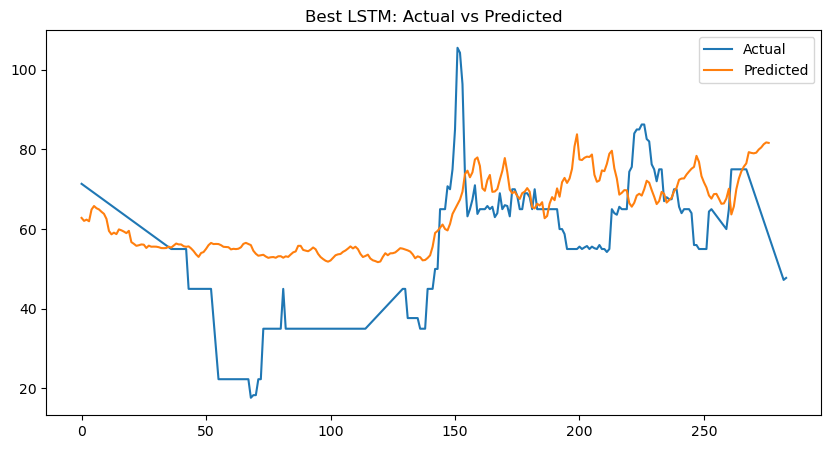

In [60]:
model = best_model
model.eval()
with torch.no_grad():
    y_pred = model(X_seq[split:]).numpy()
    y_true = y_scaled[split:]

y_pred_inv = scaler_y.inverse_transform(y_pred)
y_true_inv = scaler_y.inverse_transform(y_true)

plt.figure(figsize=(10,5))
plt.plot(y_true_inv, label="Actual")
plt.plot(y_pred_inv, label="Predicted")
plt.title("Best LSTM: Actual vs Predicted")
plt.legend()
plt.show()
